# Fake Job Posting Detection - Model Training

This notebook trains a machine learning model to classify job postings as **Real** or **Fraudulent**.

### Pipeline
- Load preprocessed dataset
- Train-Test Split
- TF-IDF Vectorization
- SMOTE for class balancing
- XGBoost Classifier
- Model Evaluation
- SHAP Explainability
- Save trained model artifacts

In [2]:
# ==========================================
# Import Required Libraries
# ==========================================

import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    classification_report,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from imblearn.over_sampling import SMOTE

import xgboost as xgb
import shap

import matplotlib.pyplot as plt

print("Libraries Imported Successfully.")

Libraries Imported Successfully.


# Load the Preprocessed Dataset

The cleaned dataset generated during preprocessing is loaded.

Target Variable:
- `fraudulent`

Input Feature:
- `combined_text`

In [5]:
# ==========================================
# Load Dataset
# ==========================================

df = pd.read_csv("../processed_data/preprocessed_cleaned.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (15665, 21)


,title,location,company_profile,description,requirements,telecommuting,has_company_logo,has_questions,employment_type,required_experience,...,industry,fraudulent,combined_text,employment_type_enc,required_experience_enc,required_education_enc,company_profile_missing,requirements_missing,industry_missing,location_missing
0,Marketing Intern,"US, NY, New York","We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,0,1,0,Other,Internship,...,NaN,0,marketing intern we re food52 and we ve create...,2,4,9,0,0,1,0
1,Customer Service - Cloud Video Production,"NZ, , Auckland","90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,0,1,0,Full-time,Not Applicable,...,Marketing and Advertising,0,customer service cloud video production 90 sec...,1,6,9,0,0,0,0
2,Commissioning Machinery Assistant (CMA),"US, IA, Wever",Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,0,1,0,Unknown,Unknown,...,NaN,0,commissioning machinery assistant cma valor se...,5,7,9,0,0,1,0
3,Account Executive - Washington DC,"US, DC, Washington",Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",0,1,0,Full-time,Mid-Senior level,...,Computer Software,0,account executive washington dc our passion fo...,1,5,1,0,0,0,0
4,Bill Review Manager,"US, FL, Fort Worth",SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,0,1,1,Full-time,Mid-Senior level,...,Hospital & Health Care,0,bill review manager spotsource solutions llc i...,1,5,1,0,0,0,0


In [6]:
# ==========================================
# Define Features and Target
# ==========================================

X = df["combined_text"]
y = df["fraudulent"]

print("Feature Shape :", X.shape)
print("Target Shape  :", y.shape)

Feature Shape : (15665,)
Target Shape  : (15665,)


# Train-Test Split

The dataset is split into:

- 80% Training
- 20% Testing

Stratified sampling is used to preserve the class distribution.

In [7]:
# ==========================================
# Train-Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training Samples :", len(X_train))
print("Testing Samples  :", len(X_test))

Training Samples : 12532
Testing Samples  : 3133


# TF-IDF Vectorization

Convert job descriptions into numerical vectors using TF-IDF.

In [8]:
# ==========================================
# TF-IDF Vectorizer
# ==========================================

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=3
)

X_train_vec = tfidf.fit_transform(X_train)

X_test_vec = tfidf.transform(X_test)

print("Training Matrix :", X_train_vec.shape)
print("Testing Matrix  :", X_test_vec.shape)

Training Matrix : (12532, 5000)
Testing Matrix  : (3133, 5000)


# Handle Class Imbalance using SMOTE

SMOTE creates synthetic samples of the minority class to balance the training dataset.

In [9]:
# ==========================================
# Apply SMOTE
# ==========================================

smote = SMOTE(random_state=42)

X_train_bal, y_train_bal = smote.fit_resample(
    X_train_vec,
    y_train
)

print("Before SMOTE")
print(y_train.value_counts())

print("\nAfter SMOTE")
print(pd.Series(y_train_bal).value_counts())

Before SMOTE
fraudulent
0    11970
1      562
Name: count, dtype: int64

After SMOTE
fraudulent
0    11970
1    11970
Name: count, dtype: int64


In [ ]:
# Train XGBoost Classifier

In [10]:
# ==========================================
# XGBoost Model
# ==========================================

clf = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    eval_metric="logloss",
    random_state=42
)

clf.fit(
    X_train_bal,
    y_train_bal
)

print("Model Trained Successfully.")

Model Trained Successfully.


In [ ]:
# Model Evaluation

In [11]:
# ==========================================
# Predictions
# ==========================================

preds = clf.predict(X_test_vec)

probs = clf.predict_proba(X_test_vec)[:,1]

In [12]:
# ==========================================
# Classification Report
# ==========================================

print(classification_report(
    y_test,
    preds,
    digits=3
))

print("PR-AUC:",
      average_precision_score(
          y_test,
          probs
      ))

              precision    recall  f1-score   support

           0      0.983     0.994     0.989      2992
           1      0.833     0.638     0.723       141

    accuracy                          0.978      3133
   macro avg      0.908     0.816     0.856      3133
weighted avg      0.976     0.978     0.977      3133

PR-AUC: 0.8312302665739989


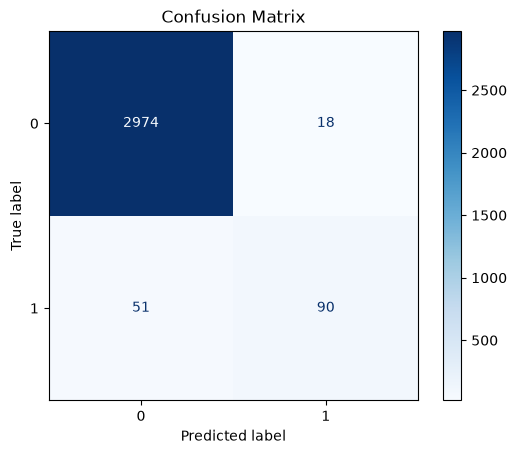

In [13]:
# ==========================================
# Confusion Matrix
# ==========================================

cm = confusion_matrix(
    y_test,
    preds
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

# SHAP Explainability

SHAP helps explain why the model predicted a job posting as fraudulent or genuine.

In [14]:
# ==========================================
# Create SHAP Explainer
# ==========================================

explainer = shap.TreeExplainer(clf)

print("SHAP Explainer Created.")

SHAP Explainer Created.


In [15]:
# ==========================================
# Example SHAP Values
# ==========================================

sample = X_test_vec[:1]

shap_values = explainer.shap_values(sample)

print("SHAP values generated for one sample.")

SHAP values generated for one sample.


# Save Model Artifacts

Save everything required for deployment.

Files generated:

- tfidf_vectorizer.joblib
- xgb_model.joblib
- shap_explainer.joblib

In [16]:
# ==========================================
# Save Model
# ==========================================

joblib.dump(
    tfidf,
    "tfidf_vectorizer.joblib"
)

joblib.dump(
    clf,
    "xgb_model.joblib"
)

joblib.dump(
    explainer,
    "shap_explainer.joblib"
)

print("Files Saved Successfully!")

Files Saved Successfully!


# Conclusion

The machine learning pipeline successfully:

- Loaded the cleaned dataset
- Performed train-test split
- Converted text into TF-IDF vectors
- Balanced the dataset using SMOTE
- Trained an XGBoost classifier
- Evaluated the model
- Generated a SHAP explainer for model interpretability
- Saved all artifacts for deployment

The saved model can now be integrated into a Flask or Streamlit application for real-time fake job detection.